In [1]:
!pip install pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 8.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
import shap

import xgboost as xgb
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data import GroupNormalizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [ ]:
def reduce_mem_usage(df, verbose=False):
    for col in df.select_dtypes(include=['object']).columns:
        if col != 'date':
            df[col] = df[col].astype('category')
            
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    return df


def wape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def picp(y_true, y_lower, y_upper):
    hits = (y_true >= y_lower) & (y_true <= y_upper)
    return np.mean(hits) * 100

def mpiw(y_lower, y_upper):
    return np.mean(y_upper - y_lower)

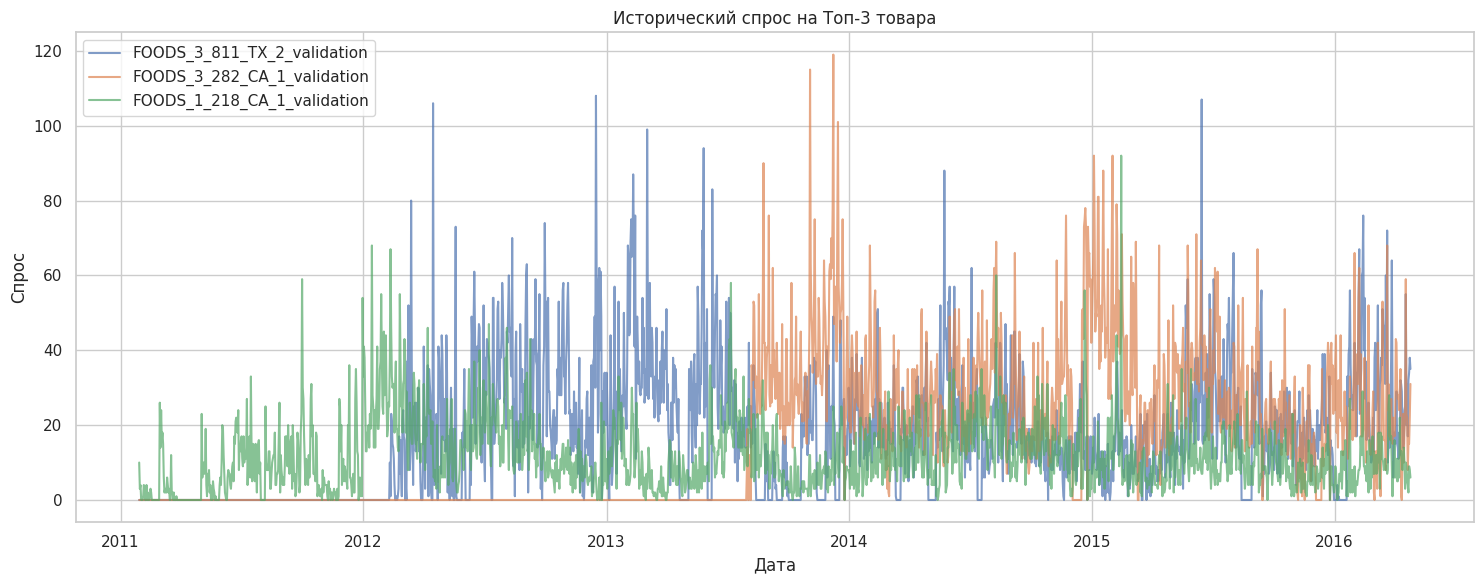

In [ ]:
path_m5 = '/kaggle/input/competitions/m5-forecasting-accuracy/'
path_macro = '/kaggle/input/datasets/sarthmirashi07/us-macroeconomic-data/US_macroeconomics.csv'

calendar = pd.read_csv(f'{path_m5}calendar.csv')
sales = pd.read_csv(f'{path_m5}sales_train_validation.csv')
prices = pd.read_csv(f'{path_m5}sell_prices.csv')

macro_df = pd.read_csv(path_macro)
macro_df['date'] = pd.to_datetime(macro_df['date'])
macro_df['year'] = macro_df['date'].dt.year
macro_df['month'] = macro_df['date'].dt.month

#cдвигаем даты публикации макростатистики на месяц вперед
macro_df['date'] = macro_df['date'] + pd.DateOffset(months=1)

calendar['date'] = pd.to_datetime(calendar['date'])
calendar['year'] = calendar['date'].dt.year
calendar['month'] = calendar['date'].dt.month

#cоединяем по точной дате (макроданные привяжутся только к 1-м числам месяца)
calendar = calendar.merge(
    macro_df[['date', 'CPI', 'Unemp_rate', 'Personal_consumption_expenditure']], 
    on='date', 
    how='left'
)

#линейная интерполяция макроданных
calendar[['CPI', 'Unemp_rate', 'Personal_consumption_expenditure']] = \
    calendar[['CPI', 'Unemp_rate', 'Personal_consumption_expenditure']].interpolate(method='linear').bfill().ffill()

#применяем оптимизацию памяти
calendar = reduce_mem_usage(calendar)
sales = reduce_mem_usage(sales)
prices = reduce_mem_usage(prices)

#берем один магазин и один департамент
subset_sales = sales[(sales['store_id'] == 'CA_1') & (sales['dept_id'] == 'FOODS_2')].copy()

if len(subset_sales) > 500:
    sales_cols = [col for col in subset_sales.columns if col.startswith('d_')]
    subset_sales['total_sales'] = subset_sales[sales_cols].sum(axis=1)
    subset_sales = subset_sales.nlargest(500, 'total_sales').drop(columns=['total_sales'])

df = pd.melt(subset_sales,
             id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
             var_name='d', value_name='demand')

df = df.merge(calendar, on='d', how='left')
df = df.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
df = reduce_mem_usage(df)
gc.collect()

#визуализация топ 3 товара по объему продаж
top_items = df.groupby('id')['demand'].sum().nlargest(3).index

plt.figure(figsize=(15, 6))
for item in top_items:
    item_data = df[df['id'] == item].sort_values('date')
    plt.plot(item_data['date'], item_data['demand'], alpha=0.7, label=item)

plt.title('Исторический спрос на Топ-3 товара')
plt.xlabel('Дата')
plt.ylabel('Спрос')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#обработка выбросов

def handle_anomalies(group):
    non_zero = group[group['demand'] > 0]
    if len(non_zero) < 50: 
        return group
    
    model = IsolationForest(contamination=0.01, random_state=42)
    features = non_zero[['demand']].values
    preds = model.fit_predict(features)
    
    #заменяем аномалии на NaN
    anomaly_indices = non_zero.iloc[preds == -1].index
    group.loc[anomaly_indices, 'demand'] = np.nan
    
    #сглаживание
    group['demand'] = group['demand'].interpolate(method='polynomial', order=2).fillna(0)
    return group

df = df.groupby('id', as_index=False).apply(handle_anomalies).reset_index(drop=True)

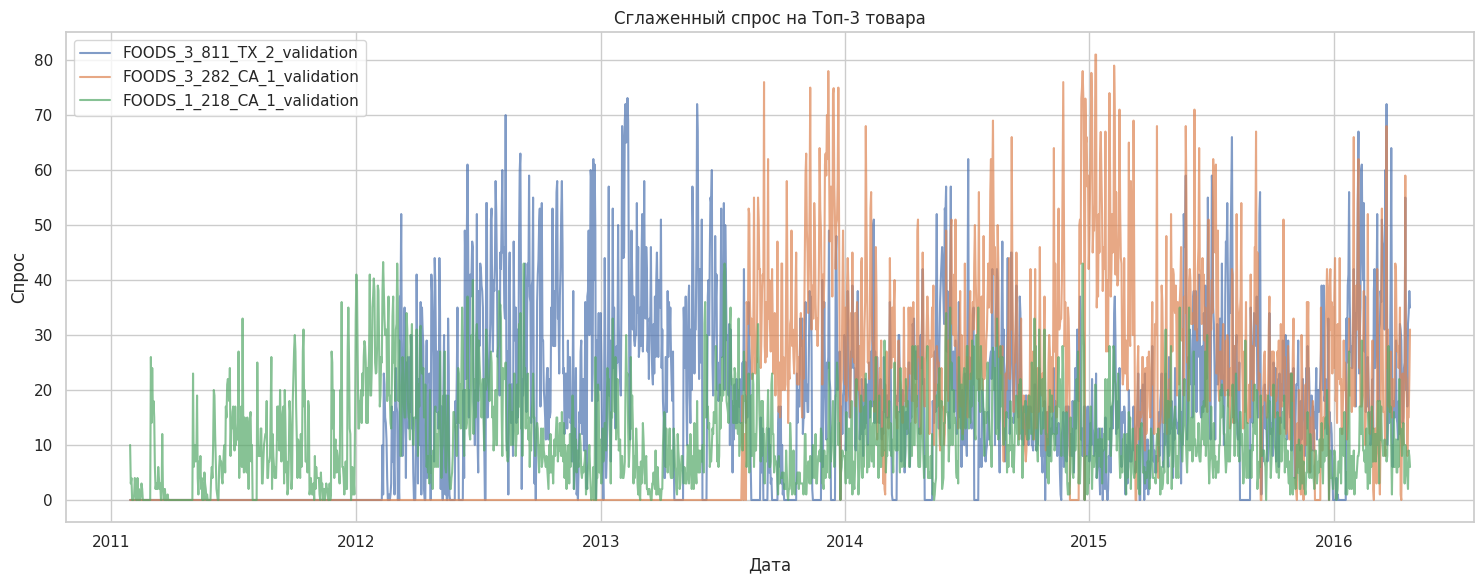

In [ ]:
#визуализация топ 3 товара после обработки выбросов
top_items = df.groupby('id')['demand'].sum().nlargest(3).index

plt.figure(figsize=(15, 6))
for item in top_items:
    item_data = df[df['id'] == item].sort_values('date')
    plt.plot(item_data['date'], item_data['demand'], alpha=0.7, label=item)

plt.title('Сглаженный спрос на топ 3 товара')
plt.xlabel('Дата')
plt.ylabel('Спрос')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#создание признаков

#тригонометрическое кодирование
df['month_sin'] = np.sin(2 * np.pi * df['month']/12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12.0)
df['dow_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek/7.0)
df['dow_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek/7.0)

#единый флаг для текущего штата
df['snap_flag'] = np.where(
    ((df['state_id'] == 'CA') & (df['snap_CA'] == 1)) |
    ((df['state_id'] == 'TX') & (df['snap_TX'] == 1)) |
    ((df['state_id'] == 'WI') & (df['snap_WI'] == 1)), 1, 0
)

#лаговые переменные и скользящие окна
df = df.sort_values(['id', 'date']).reset_index(drop=True)

for lag in [28, 35, 42]:
    df[f'demand_lag_{lag}'] = df.groupby('id')['demand'].shift(lag)

#скользящие средние и волатильность (std) по лагу 28 (чтобы избежать утечки)
df['demand_rolling_mean_28_7'] = df.groupby('id')['demand_lag_28'].transform(lambda x: x.rolling(7).mean())
df['demand_rolling_mean_28_28'] = df.groupby('id')['demand_lag_28'].transform(lambda x: x.rolling(28).mean())
df['price_volatility_28_7'] = df.groupby('id')['sell_price'].transform(lambda x: x.rolling(7).std())


numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)
df['time_idx'] = (df['date'] - df['date'].min()).dt.days

In [ ]:
class PurgedEmbargoTimeSeriesSplit:
    def __init__(self, n_splits=3, test_size=28, embargo_size=28):
        self.n_splits = n_splits
        self.test_size = test_size
        self.embargo_size = embargo_size

    def split(self, df, time_col='time_idx'):
        max_time = df[time_col].max()
        splits = []
        for i in range(self.n_splits):
            test_end = max_time - (i * self.test_size)
            test_start = test_end - self.test_size
            train_end = test_start - self.embargo_size
            
            val_idx = df[(df[time_col] > test_start) & (df[time_col] <= test_end)].index
            train_idx = df[df[time_col] <= train_end].index
            
            splits.append((train_idx, val_idx))
        return splits[::-1] 

cv = PurgedEmbargoTimeSeriesSplit(n_splits=3, test_size=28, embargo_size=28)

In [ ]:
#валидация и baseline XGBoost

cat_features = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
for col in cat_features:
    df[col] = df[col].astype('cеннategory')
    
#дополнительные длинные окна на базе 28-го лага
df['demand_rolling_mean_28_60'] = df.groupby('id')['demand_lag_28'].transform(lambda x: x.rolling(60).mean())
df['demand_rolling_max_28_28'] = df.groupby('id')['demand_lag_28'].transform(lambda x: x.rolling(28).max())

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

#используем TimeSeriesSplit с gap=28 чтобы избежать утечки
features = [
    #категориальные признаки
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 
    #календарь и цены
    'sell_price', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'snap_flag', 
    #лаги
    'demand_lag_28', 'demand_lag_35', 'demand_lag_42',
    #скользящие окна
    'demand_rolling_mean_28_7', 'demand_rolling_mean_28_28', 
    'demand_rolling_mean_28_60', 'demand_rolling_max_28_28',
    #макро
    'CPI', 'Unemp_rate', 'Personal_consumption_expenditure'
]
target = 'demand'

df[target] = df[target].clip(lower=0)

xgb_metrics = []
xgb_models = []

print("Начинаем обучение XGBoost с Purged Embargo CV...\n")
for fold, (train_idx, val_idx) in enumerate(cv.split(df)):
    X_train, y_train = df.iloc[train_idx][features], df.iloc[train_idx][target]
    X_val, y_val = df.iloc[val_idx][features], df.iloc[val_idx][target]

    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
        
        tree_method='hist',
        enable_categorical=True,
        objective='reg:tweedie', #оптимизация под прерывистый спрос (intermittent demand)
        tweedie_variance_power=1.1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    y_pred = np.maximum(0, model.predict(X_val)) 
    fold_wape = wape(y_val.values, y_pred)
    
    xgb_metrics.append({'Fold': fold+1, 'WAPE': fold_wape})
    xgb_models.append(model)
    print(f"Fold {fold+1} | WAPE: {fold_wape:.2f}% | Лучшая итерация: {model.best_iteration}")

xgb_results = pd.DataFrame(xgb_metrics)
print(f"\nСредний WAPE (XGBoost Tweedie): {xgb_results['WAPE'].mean():.2f}%")

Начинаем обучение XGBoost с Purged Embargo CV...

Fold 1 | WAPE: 72.79% | Лучшая итерация: 147
Fold 2 | WAPE: 74.23% | Лучшая итерация: 183
Fold 3 | WAPE: 73.79% | Лучшая итерация: 111

Средний WAPE (XGBoost Tweedie): 73.60%


In [ ]:
#обучение TFT
import lightning.pytorch as pl

torch.set_float32_matmul_precision('medium')
max_prediction_length = 28
max_encoder_length = 180

cat_features = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
for c in cat_features:
    df[c] = df[c].astype(str)
    
df['demand'] = df['demand'].clip(lower=0).astype(np.float32)

#обучаем на последнем фолде для корректного сравнения
test_start_time = df['time_idx'].max() - max_prediction_length
train_df = df[df['time_idx'] <= test_start_time]
test_df = df

training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="demand",
    group_ids=["id"],
    min_encoder_length=max_encoder_length // 2, 
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    
    #статичные признаки
    static_categoricals=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    
    #известные в будущем
    time_varying_known_reals=["time_idx", "month_sin", "dow_sin", "sell_price", "snap_flag"], 
    
    #неизвестные в будущем
    time_varying_unknown_reals=["demand", "demand_rolling_mean_28_7", "CPI", "Unemp_rate"],
    
    target_normalizer=GroupNormalizer(groups=["id"], transformation="softplus", center=False)
)

validation_dataset = TimeSeriesDataSet.from_dataset(training_dataset, test_df, predict=True, stop_randomization=True)

train_dataloader = training_dataset.to_dataloader(
    train=True, 
    batch_size=256,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)
val_dataloader = validation_dataset.to_dataloader(
    train=False, 
    batch_size=256,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.01,
    hidden_size=16,
    attention_head_size=8,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9])
)


trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    #strategy="auto",
    gradient_clip_val=0.1,
    enable_progress_bar=True
)
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  9.5 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    160 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  5.9 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    610 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     51 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 33.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 417                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


In [ ]:
#кастомные метрики (WAPE, PICP, MPIW)

#получение предиктов
predictions = tft.predict(val_dataloader, return_y=True, mode="quantiles")
y_true_tft = predictions.y[0].cpu().numpy().flatten()
q50 = predictions.output[:, :, 1].cpu().numpy().flatten()
q10 = predictions.output[:, :, 0].cpu().numpy().flatten()
q90 = predictions.output[:, :, 2].cpu().numpy().flatten()

tft_wape = wape(y_true_tft, q50)
print(f"\nTFT WAPE (Медиана): {tft_wape:.2f}%")
print(f"TFT PICP (Покрытие интервала): {picp(y_true_tft, q10, q90):.2f}%")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



TFT WAPE (Медиана): 72.01%
TFT PICP (Покрытие интервала): 30.92%


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



================ СРАВНЕНИЕ МОДЕЛЕЙ ================
XGBoost Tweedie WAPE (CV): 73.60%
TFT WAPE (Медиана на Test): 72.01%
TFT PICP (Покрытие 80% интервала): 30.92%



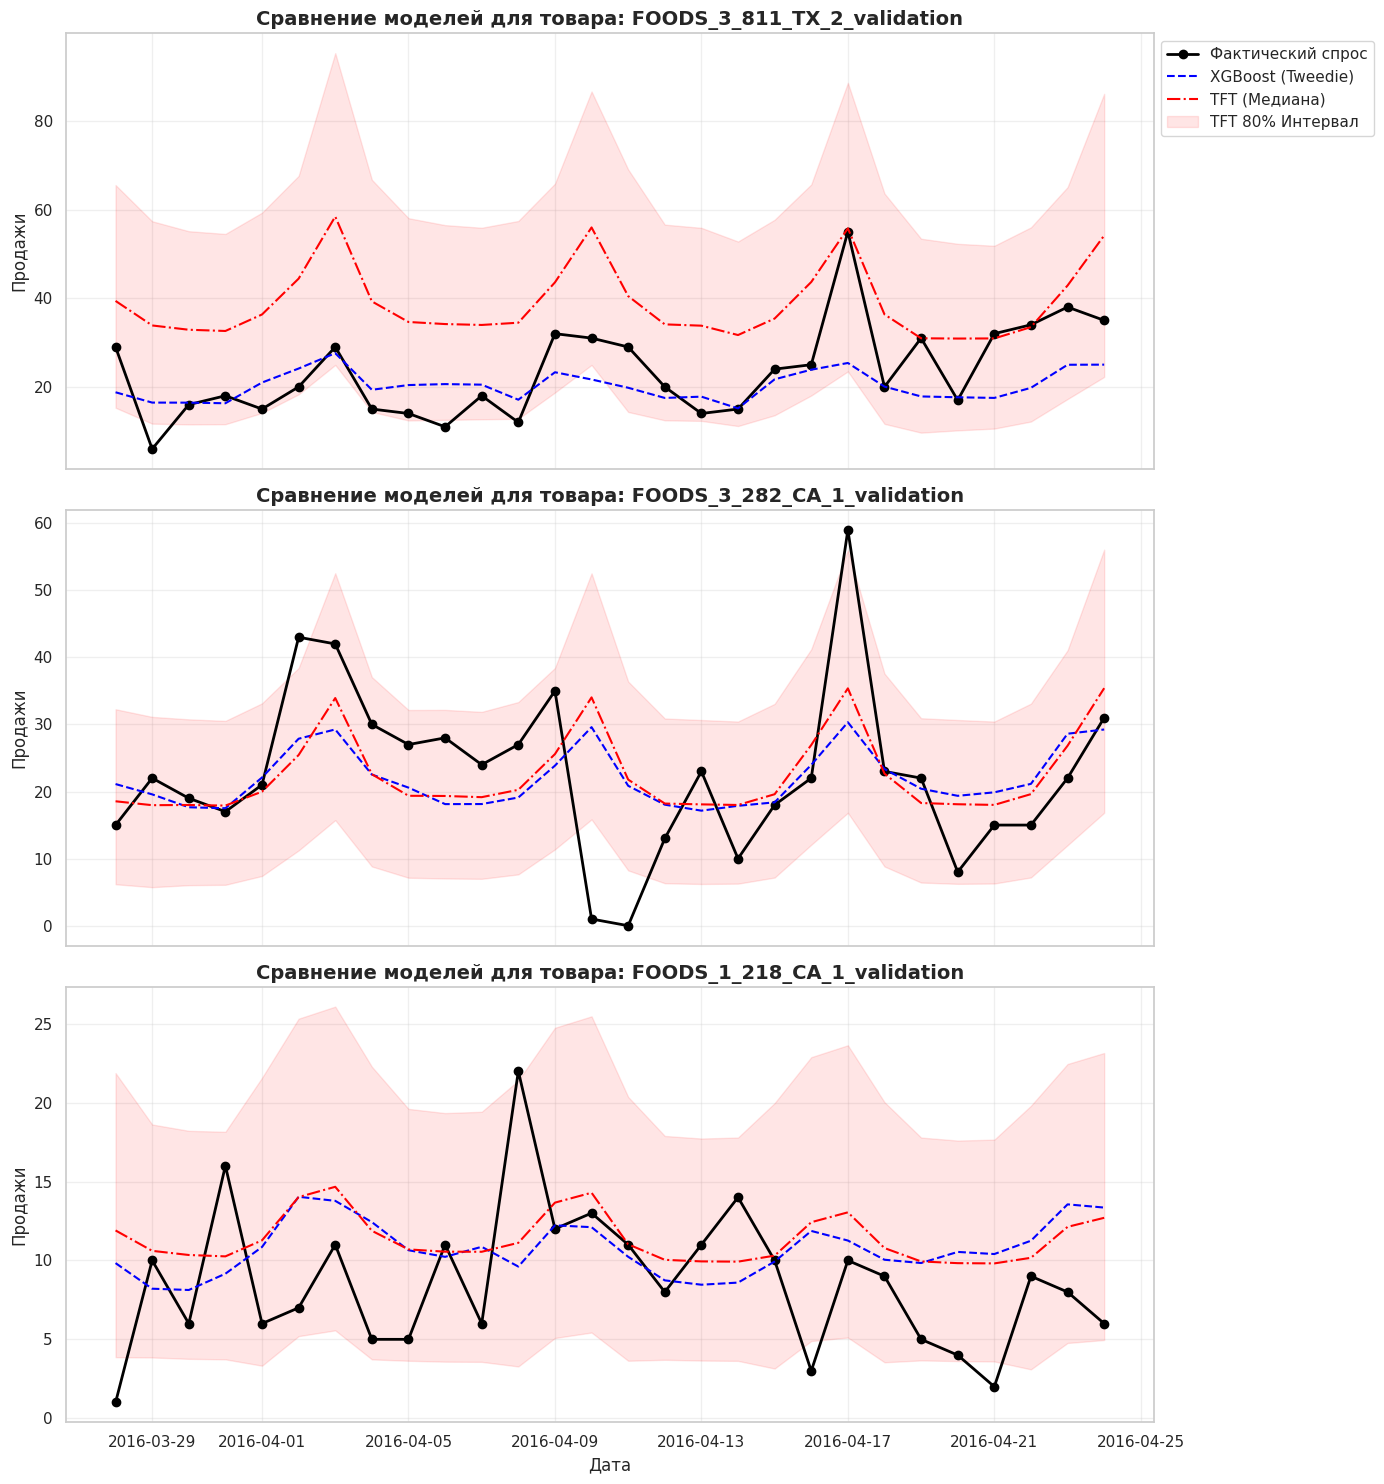


Отрисовка SHAP для XGBoost...


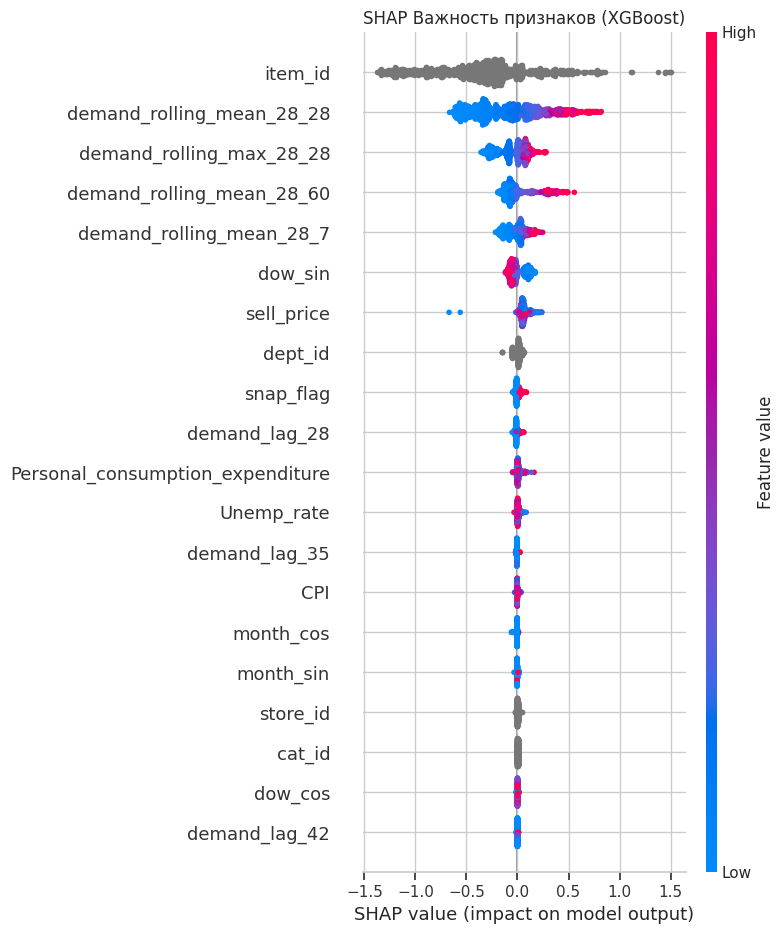


Отрисовка важности признаков TFT...


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


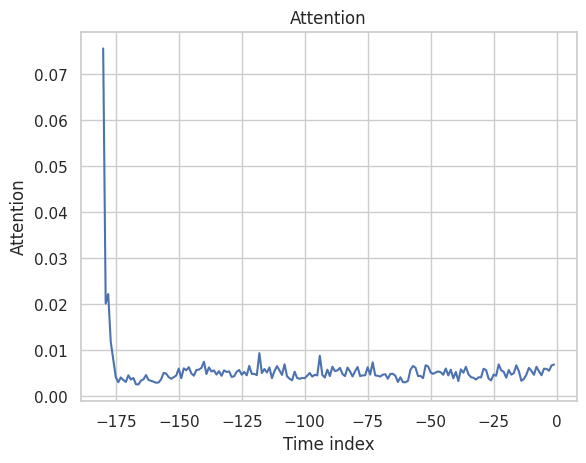

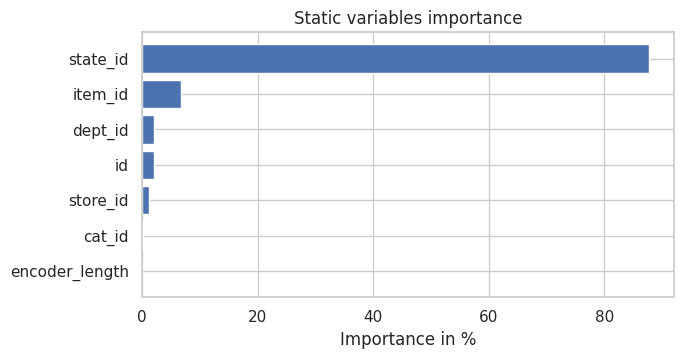

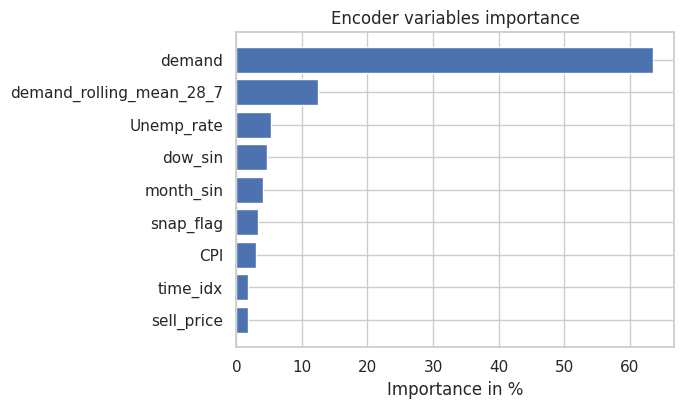

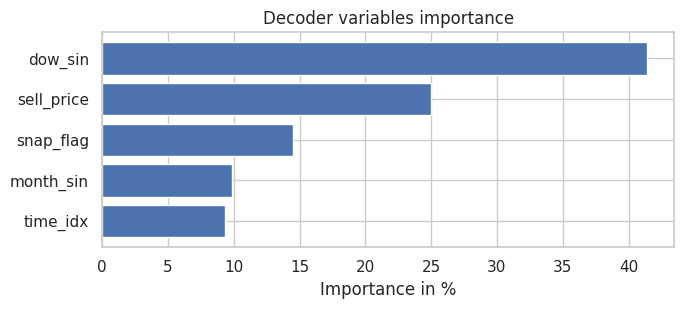

In [ ]:
#получение предиктов от TFT 
predictions = tft.predict(val_dataloader, return_y=True, return_index=True, mode="quantiles")

y_true_tft = predictions.y[0].cpu().numpy().flatten()
q10 = predictions.output[:, :, 0].cpu().numpy().flatten()
q50 = predictions.output[:, :, 1].cpu().numpy().flatten()
q90 = predictions.output[:, :, 2].cpu().numpy().flatten()

tft_wape = wape(y_true_tft, q50)
tft_picp = picp(y_true_tft, q10, q90)

print(f"\n================ СРАВНЕНИЕ МОДЕЛЕЙ ================")
print(f"XGBoost Tweedie WAPE (CV): {xgb_results['WAPE'].mean():.2f}%")
print(f"TFT WAPE (Медиана на Test): {tft_wape:.2f}%")
print(f"TFT PICP (Покрытие 80% интервала): {tft_picp:.2f}%")
print(f"===================================================\n")


#визуальное сравнение на топ 3 товарах
#находим топ 3 товара по суммарному спросу за всю историю
top_3_ids = df.groupby('id')['demand'].sum().nlargest(3).index.tolist()

fig, axes = plt.subplots(len(top_3_ids), 1, figsize=(14, 5 * len(top_3_ids)), sharex=True)
if len(top_3_ids) == 1:
    axes = [axes]

cat_features = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
xgb_best = xgb_models[-1] # Лучший XGBoost с прошлого шага

for i, item_id in enumerate(top_3_ids):
    val_df_sample = df[(df['id'] == item_id) & (df['time_idx'] > test_start_time)].copy()
    
    #возвращаем тип 'category' для XGBoost
    for col in cat_features:
        val_df_sample[col] = val_df_sample[col].astype('category')
        
    #предикт XGBoost
    xgb_preds = np.maximum(0, xgb_best.predict(val_df_sample[features]))
    
    #предикт TFT
    item_idx = np.where(predictions.index['id'] == item_id)[0]
    if len(item_idx) > 0:
        tft_sample_preds = predictions.output[item_idx[0], :, 1].cpu().numpy()
        tft_sample_q10 = predictions.output[item_idx[0], :, 0].cpu().numpy()
        tft_sample_q90 = predictions.output[item_idx[0], :, 2].cpu().numpy()
    else:
        tft_sample_preds = np.zeros(len(val_df_sample))
        tft_sample_q10 = np.zeros(len(val_df_sample))
        tft_sample_q90 = np.zeros(len(val_df_sample))

    ax = axes[i]
    ax.plot(val_df_sample['date'], val_df_sample['demand'], label='Фактический спрос', marker='o', color='black', linewidth=2)
    ax.plot(val_df_sample['date'], xgb_preds, label='XGBoost (Tweedie)', linestyle='--', color='blue')
    ax.plot(val_df_sample['date'], tft_sample_preds, label='TFT (Медиана)', linestyle='-.', color='red')
    
    #доверительный интервал
    if len(item_idx) > 0:
        ax.fill_between(val_df_sample['date'], tft_sample_q10, tft_sample_q90, color='red', alpha=0.1, label='TFT 80% Интервал')

    ax.set_title(f'Сравнение моделей для товара: {item_id}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Продажи')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.xlabel('Дата', fontsize=12)
plt.tight_layout()
plt.show()

#SHAP (XGBoost)
print("\nОтрисовка SHAP для XGBoost...")
explainer = shap.TreeExplainer(xgb_best)
x_val_sample = df[df['time_idx'] > test_start_time][features].sample(min(1000, len(df)), random_state=42).copy()

for col in cat_features:
    x_val_sample[col] = x_val_sample[col].astype('category')

shap_values = explainer.shap_values(x_val_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_val_sample, show=False)
plt.title("SHAP Важность признаков (XGBoost)")
plt.tight_layout()
plt.show()

print("\nОтрисовка важности признаков TFT...")
best_tft = TemporalFusionTransformer.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
figs = best_tft.plot_interpretation(interpretation)
figs['encoder_variables'].show()